In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Charger le dataset Iris
iris = load_iris()

# Convertir en DataFrame pour mieux visualiser
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Afficher les 5 premières lignes
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
# Dimensions du dataset
print("Taille du dataset:", df.shape)

# Statistiques générales
print("\nStatistiques générales:")
df.describe()

Taille du dataset: (150, 6)

Statistiques générales:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


C:\Users\RPC\AppData\Local\Temp\ipykernel_7880\3668558579.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species_name', data=df, palette='Set2')


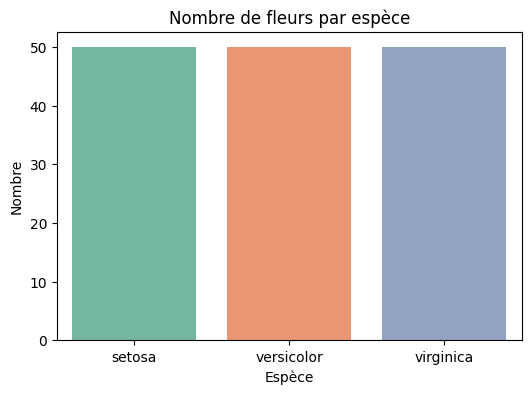

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='species_name', data=df, palette='Set2')
plt.title("Nombre de fleurs par espèce")
plt.xlabel("Espèce")
plt.ylabel("Nombre")
plt.show()

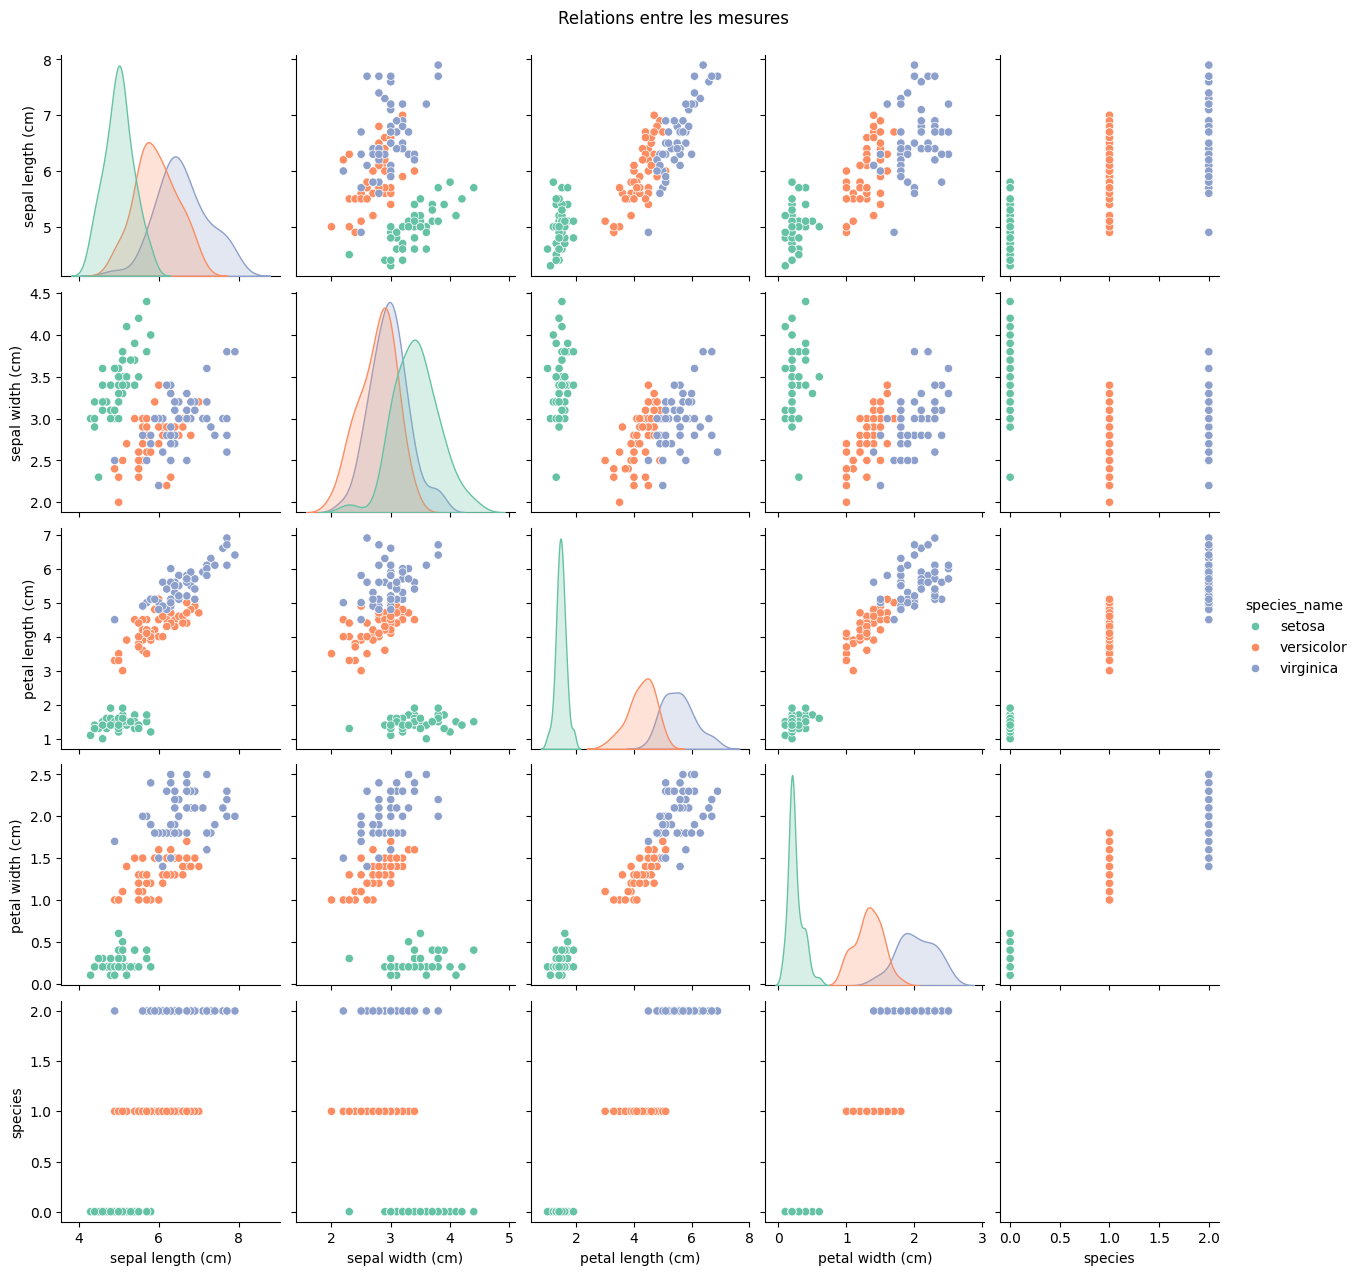

In [5]:
sns.pairplot(df, hue='species_name', palette='Set2')
plt.suptitle("Relations entre les mesures", y=1.02)
plt.show()

In [6]:
# Séparer les features (X) et la cible (y)
X = iris.data
y = iris.target

# Diviser en données d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Taille entraînement:", X_train.shape)
print("Taille test:", X_test.shape)

Taille entraînement: (120, 4)
Taille test: (30, 4)


In [7]:
# Créer et entraîner le modèle KNN
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

print("Modèle entraîné avec succès ✅")

Modèle entraîné avec succès ✅


In [8]:
# Faire des prédictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle : {accuracy * 100:.2f}%")

# Rapport détaillé
print("\nRapport de classification:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Précision du modèle : 100.00%

Rapport de classification:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



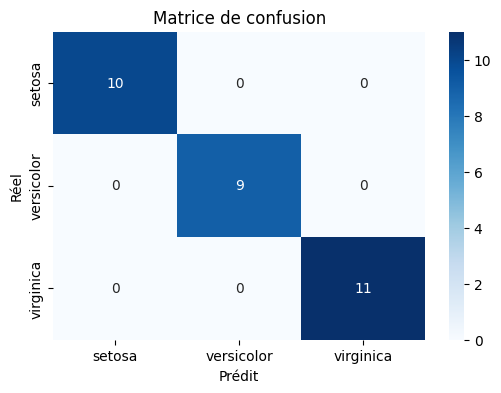

In [9]:
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()